# Eye Modality — Open/Closed Eye CNN

**Driver Fatigue Detection — Signal Modality Comparison**
*BSc Computing Dissertation — Leon Dupree*

This notebook trains and evaluates a small convolutional neural network that
classifies cropped eye images as **open** or **closed**. The trained model
feeds into a downstream PERCLOS (Percentage of Eye Closure) estimator that
flags fatigue when sustained eye closure exceeds a threshold over a rolling
window.

**Dataset:** MRL Eye Dataset (Kaggle mirror by *imadeddinedjerarda*) — ~84,900
cropped eye images across 37 subjects, varied lighting and resolution. The
Kaggle version organises images into two folders:

```
mrleyedataset/
├── Close-Eyes/    (~41,900 images)
└── Open-Eyes/     (~43,000 images)
```

The original MRL filename format is preserved (e.g. `s0001_01842_0_0_1_0_0_01.png`),
so we can extract subject IDs from filenames and use the folder name for the
class label.

**Methodology notes:**
- Train / validation / test split is **subject-level** (different subjects in
  each split). Random frame-level splitting would leak between splits because
  consecutive frames of the same eye are nearly identical, inflating
  validation accuracy.
- Reported metrics: accuracy, precision, recall, F1-score, confusion matrix.
- Model architecture is a small CNN (~550K parameters), defined in
  `src/eye/model.py`. Kept small to be comparable in capacity to the MLPs
  used for the other three modalities.


## 1. Setup and imports

In [1]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

# Make src/ importable from this notebook
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.eye.model import SmallCNN

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:             {torch.cuda.get_device_name(0)}")


PyTorch version: 2.5.1+cu121
CUDA available:  True
GPU:             NVIDIA GeForce RTX 3070


In [3]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


## 2. Loading the MRL Eye Dataset

### Expected folder structure

After downloading the Kaggle MRL Eye Dataset and extracting it, the layout
should be:

```
fatigue-detection/
└── data/
    └── mrl_eye/
        ├── Close-Eyes/
        │   ├── s0001_00012_0_0_0_0_0_01.png
        │   └── ...
        └── Open-Eyes/
            ├── s0001_01842_0_0_1_0_0_01.png
            └── ...
```

If your extracted folder is named `mrleyedataset` instead of `mrl_eye`,
either rename it or update `DATA_DIR` below.

### Filename format

Each filename is `s{subject}_{image}_{gender}_{glasses}_{eye_state}_{reflection}_{lighting}_{sensor}.png`.
We extract:
- `subject` (e.g. `s0001`) — used for the train/val/test split
- `glasses` and `lighting` — used for slice analysis in the dissertation

The label comes from the parent folder name (`Open-Eyes` or `Close-Eyes`),
which is more reliable than parsing the eye_state field in the filename.


In [4]:
DATA_DIR = PROJECT_ROOT / "data" / "mrl_eye"

# Look for the two label folders. Accept either the renamed 'mrl_eye' or
# the original Kaggle 'mrleyedataset' folder name.
candidate_dirs = [DATA_DIR, PROJECT_ROOT / "data" / "mrleyedataset"]
DATA_DIR = next((d for d in candidate_dirs if (d / "Open-Eyes").exists()), None)

if DATA_DIR is None:
    raise FileNotFoundError(
        "Dataset not found.\n"
        f"Looked for an 'Open-Eyes' subfolder inside any of: {[str(d) for d in candidate_dirs]}\n"
        "Download the MRL Eye Dataset from Kaggle and extract it so that\n"
        "data/mrl_eye/Open-Eyes/ and data/mrl_eye/Close-Eyes/ both exist."
    )

print(f"Using dataset at: {DATA_DIR}")
open_files  = sorted((DATA_DIR / "Open-Eyes").glob("*.png"))
close_files = sorted((DATA_DIR / "Close-Eyes").glob("*.png"))
print(f"  Open-Eyes:  {len(open_files):,} images")
print(f"  Close-Eyes: {len(close_files):,} images")
print(f"  Total:      {len(open_files) + len(close_files):,} images")


Using dataset at: C:\Dissertation\fatigue-detection\data\mrleyedataset
  Open-Eyes:  42,952 images
  Close-Eyes: 41,946 images
  Total:      84,898 images


In [5]:
def parse_mrl_filename(path: Path, label: int) -> dict | None:
    """Parse an MRL filename. Returns None if the format doesn't match."""
    stem = path.stem
    parts = stem.split("_")
    if len(parts) < 8 or not parts[0].startswith("s"):
        # Filename doesn't follow MRL format — keep the file but with default metadata
        return {
            "path": str(path),
            "subject": "unknown",
            "image_id": stem,
            "gender": -1,
            "glasses": -1,
            "eye_state": label,
            "reflection": -1,
            "lighting": -1,
            "sensor": "unknown",
        }
    try:
        return {
            "path": str(path),
            "subject": parts[0],            # e.g. "s0001"
            "image_id": parts[1],
            "gender": int(parts[2]),        # 0=male, 1=female
            "glasses": int(parts[3]),       # 0=no, 1=yes
            "eye_state": label,             # use folder label, not parts[4]
            "reflection": int(parts[5]),
            "lighting": int(parts[6]),
            "sensor": parts[7],
        }
    except ValueError:
        return None

# Build a DataFrame of every image, with label from the folder
records = []
for p in open_files:
    rec = parse_mrl_filename(p, label=1)   # 1 = open
    if rec is not None:
        records.append(rec)
for p in close_files:
    rec = parse_mrl_filename(p, label=0)   # 0 = closed
    if rec is not None:
        records.append(rec)

df = pd.DataFrame(records)
print(f"Parsed {len(df):,} valid records")

print(f"\nClass balance:")
print(df["eye_state"].value_counts().rename({0: "closed", 1: "open"}))

print(f"\nUnique subjects: {df['subject'].nunique()}")
print(f"\nTop subjects by image count:")
print(df["subject"].value_counts().head())


Parsed 84,898 valid records

Class balance:
eye_state
open      42952
closed    41946
Name: count, dtype: int64

Unique subjects: 37

Top subjects by image count:
subject
s0037    10257
s0014     8884
s0012     8728
s0036     6193
s0019     6175
Name: count, dtype: int64


## 3. Subject-level train / validation / test split

**Why this matters:** if we randomly split the ~85,000 images, frames of the
same person's eye end up in both train and test. The model then "passes"
the test by recognising the person, not by understanding eye state. This is
a common, easy mistake to make and it's what examiners look for.

We split *subjects* into three disjoint groups (70% train, 15% val, 15% test),
then assign every image to whichever group its subject belongs to. The model
never sees any frames from a test subject during training.


In [6]:
subjects = sorted(df["subject"].unique())
print(f"Total unique subjects: {len(subjects)}")

rng = np.random.default_rng(SEED)
shuffled = rng.permutation(subjects)

n = len(shuffled)
n_train = int(0.70 * n)
n_val = int(0.15 * n)

train_subjects = set(shuffled[:n_train])
val_subjects = set(shuffled[n_train:n_train + n_val])
test_subjects = set(shuffled[n_train + n_val:])

assert train_subjects.isdisjoint(val_subjects)
assert train_subjects.isdisjoint(test_subjects)
assert val_subjects.isdisjoint(test_subjects)

df["split"] = df["subject"].apply(
    lambda s: "train" if s in train_subjects
    else "val" if s in val_subjects
    else "test"
)

print("\nSubjects per split:")
print(f"  train: {len(train_subjects)}")
print(f"  val:   {len(val_subjects)}")
print(f"  test:  {len(test_subjects)}")

print("\nImages per split:")
print(df["split"].value_counts())

print("\nClass balance per split:")
print(pd.crosstab(df["split"], df["eye_state"].map({0: "closed", 1: "open"})))


Total unique subjects: 37

Subjects per split:
  train: 25
  val:   5
  test:  7

Images per split:
split
train    42483
val      23287
test     19128
Name: count, dtype: int64

Class balance per split:
eye_state  closed   open
split                   
test         8690  10438
train       21825  20658
val         11431  11856


## 4. Dataset class with augmentation

Augmentation applies only to the training set. Validation and test sets get
deterministic preprocessing only — no augmentation, no randomness.


In [7]:
IMG_SIZE = 64

train_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])

eval_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])


class EyeDataset(Dataset):
    """PyTorch Dataset for MRL eye images."""

    def __init__(self, frame: pd.DataFrame, transform):
        self.paths = frame["path"].tolist()
        self.labels = frame["eye_state"].tolist()
        self.transform = transform

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, idx: int):
        path = self.paths[idx]
        label = self.labels[idx]
        img = Image.open(path).convert("RGB")
        x = self.transform(img)
        return x, torch.tensor(label, dtype=torch.long)


train_ds = EyeDataset(df[df.split == "train"], train_transform)
val_ds   = EyeDataset(df[df.split == "val"],   eval_transform)
test_ds  = EyeDataset(df[df.split == "test"],  eval_transform)

print(f"Train: {len(train_ds):,}  Val: {len(val_ds):,}  Test: {len(test_ds):,}")


Train: 42,483  Val: 23,287  Test: 19,128


In [9]:
BATCH_SIZE = 128
NUM_WORKERS = 0   # Windows + Jupyter sometimes hangs with workers > 0; safe default

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                     num_workers=NUM_WORKERS, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                     num_workers=NUM_WORKERS, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                     num_workers=NUM_WORKERS, pin_memory=True)


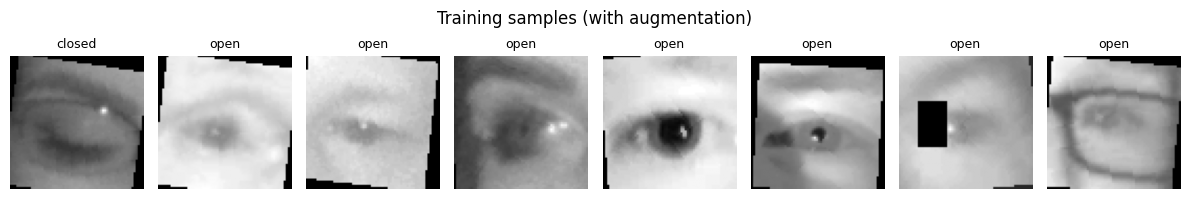

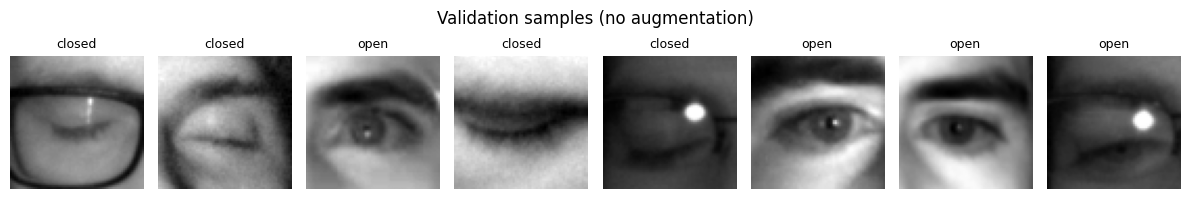

In [10]:
# Visualise a few training samples to confirm augmentation is sensible
def show_samples(dataset, n=8, title="Samples"):
    fig, axes = plt.subplots(1, n, figsize=(n * 1.5, 2))
    label_names = {0: "closed", 1: "open"}
    for i in range(n):
        idx = random.randint(0, len(dataset) - 1)
        x, y = dataset[idx]
        axes[i].imshow(x.squeeze().numpy(), cmap="gray")
        axes[i].set_title(label_names[int(y)], fontsize=9)
        axes[i].axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

show_samples(train_ds, title="Training samples (with augmentation)")
show_samples(val_ds,   title="Validation samples (no augmentation)")


## 5. Model

The CNN architecture is defined in `src/eye/model.py` and imported here.
Three conv blocks reduce spatial dimensions from 64×64 to 8×8, then a
2-layer classifier head maps to 2 logits.


In [11]:
model = SmallCNN(num_classes=2, dropout=0.3).to(DEVICE)
print(model)
print(f"\nTrainable parameters: {model.count_parameters():,}")


SmallCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=4096, out_features=128, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)

Trainable parameters: 547,970


## 6. Training

We track training and validation loss/accuracy each epoch, and save the
weights that achieved the best **validation accuracy**. The test set is
not touched during training — we evaluate on it once at the end.


In [12]:
EPOCHS = 15
LEARNING_RATE = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn = nn.CrossEntropyLoss()

# Save best weights to project models/ directory
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
BEST_WEIGHTS_PATH = MODELS_DIR / "eye_cnn.pt"

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0


def run_epoch(loader, training: bool):
    """Run one pass over the loader. Returns (loss, accuracy)."""
    model.train(training)
    total_loss, total_correct, total_n = 0.0, 0, 0
    context = torch.enable_grad() if training else torch.no_grad()

    desc = "train" if training else "val"
    with context:
        for x, y in tqdm(loader, desc=desc, leave=False):
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss = loss_fn(logits, y)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * x.size(0)
            total_correct += (logits.argmax(1) == y).sum().item()
            total_n += x.size(0)

    return total_loss / total_n, total_correct / total_n


for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_dl, training=True)
    val_loss, val_acc = run_epoch(val_dl, training=False)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    marker = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_WEIGHTS_PATH)
        marker = "  <- best, saved"

    print(f"Epoch {epoch:2d}/{EPOCHS}  "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.3f}  "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.3f}{marker}")

print(f"\nBest validation accuracy: {best_val_acc:.3f}")
print(f"Saved best weights to: {BEST_WEIGHTS_PATH}")


train:   0%|          | 0/332 [00:00<?, ?it/s]

val:   0%|          | 0/182 [00:00<?, ?it/s]

Epoch  1/15  train_loss=0.4679 train_acc=0.767  val_loss=0.4848 val_acc=0.791  <- best, saved


train:   0%|          | 0/332 [00:00<?, ?it/s]

val:   0%|          | 0/182 [00:00<?, ?it/s]

...

val:   0%|          | 0/182 [00:00<?, ?it/s]

Epoch 14/15  train_loss=0.0776 train_acc=0.972  val_loss=0.1425 val_acc=0.953  <- best, saved


train:   0%|          | 0/332 [00:00<?, ?it/s]

val:   0%|          | 0/182 [00:00<?, ?it/s]

Epoch 15/15  train_loss=0.0747 train_acc=0.973  val_loss=0.1815 val_acc=0.950

Best validation accuracy: 0.953
Saved best weights to: C:\Dissertation\fatigue-detection\models\eye_cnn.pt


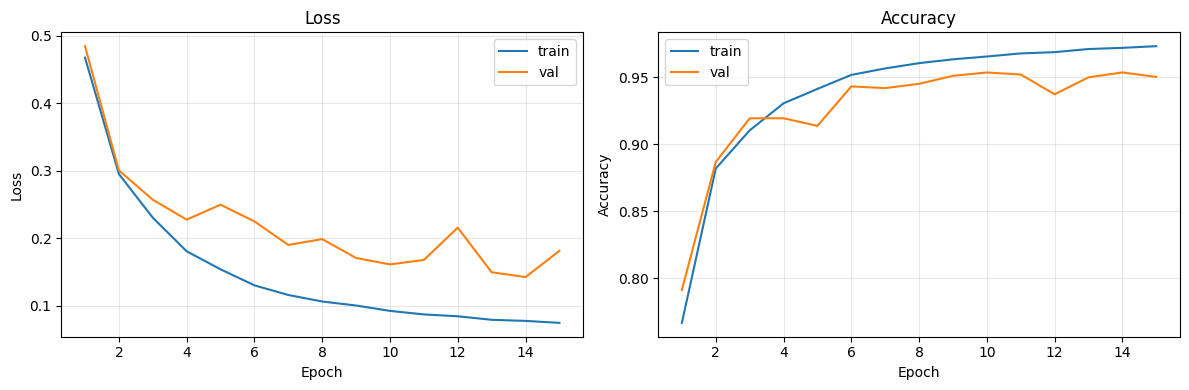

In [14]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_x = range(1, len(history["train_loss"]) + 1)
ax1.plot(epochs_x, history["train_loss"], label="train")
ax1.plot(epochs_x, history["val_loss"], label="val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("Loss")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_x, history["train_acc"], label="train")
ax2.plot(epochs_x, history["val_acc"], label="val")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.set_title("Accuracy")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "eye_training_curves.png", dpi=120)
plt.show()


## 7. Test set evaluation

Now we load the best weights and evaluate on the held-out test set —
**subjects the model has never seen during training**. These are the
numbers that go in the dissertation.


In [15]:
# Load best weights
model.load_state_dict(torch.load(BEST_WEIGHTS_PATH, map_location=DEVICE))
model.eval()

# Run inference on test set
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for x, y in tqdm(test_dl, desc="Test"):
        x = x.to(DEVICE)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(y.tolist())
        all_probs.extend(probs[:, 1].cpu().tolist())   # P(open)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# Headline metrics
acc = accuracy_score(all_labels, all_preds)
prec, rec, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="binary", pos_label=1
)

print(f"Test set: {len(all_labels):,} images from {len(test_subjects)} subjects")
print(f"\nAccuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}  (positive class = open)")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\n" + classification_report(
    all_labels, all_preds, target_names=["closed", "open"], digits=4
))


C:\Users\leonf\AppData\Local\Temp\ipykernel_25140\3781354148.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(BEST_WEIGHTS_PATH, map_loca

Test:   0%|          | 0/150 [00:00<?, ?it/s]

Test set: 19,128 images from 7 subjects

Accuracy:  0.9795
Precision: 0.9811  (positive class = open)
Recall:    0.9813
F1-score:  0.9812

              precision    recall  f1-score   support

      closed     0.9776    0.9773    0.9774      8690
        open     0.9811    0.9813    0.9812     10438

    accuracy                         0.9795     19128
   macro avg     0.9793    0.9793    0.9793     19128
weighted avg     0.9795    0.9795    0.9795     19128



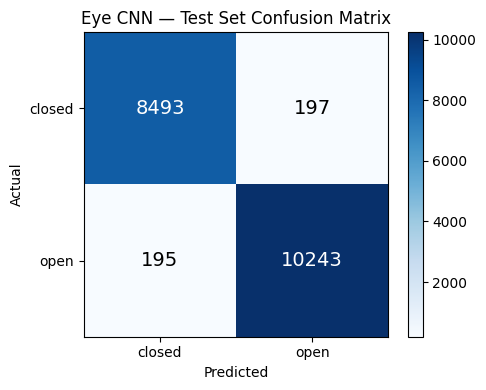

In [16]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["closed", "open"])
ax.set_yticklabels(["closed", "open"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Eye CNN — Test Set Confusion Matrix")

# Annotate cells
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black",
                fontsize=14)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "eye_confusion_matrix.png", dpi=120)
plt.show()


## 8. Slice analysis (for the dissertation)

Where does the model fail? We break down accuracy by glasses and lighting
to see whether performance varies with conditions. This generates direct
material for the dissertation's Discussion section.

(Skipped automatically if filenames don't carry the metadata — the parser
falls back to `glasses=-1`, `lighting=-1` for non-MRL filenames.)


In [17]:
test_df = df[df.split == "test"].reset_index(drop=True).copy()
test_df["pred"] = all_preds
test_df["correct"] = (test_df["pred"] == test_df["eye_state"]).astype(int)

# Only run slice analysis if metadata is present
if (test_df["glasses"] >= 0).any():
    print("Accuracy by GLASSES (0=no, 1=yes):")
    print(test_df[test_df.glasses >= 0]
            .groupby("glasses")["correct"].agg(["mean", "count"]).round(4))

if (test_df["lighting"] >= 0).any():
    print("\nAccuracy by LIGHTING (0=bad, 1=good):")
    print(test_df[test_df.lighting >= 0]
            .groupby("lighting")["correct"].agg(["mean", "count"]).round(4))

if (test_df["glasses"] >= 0).any() and (test_df["lighting"] >= 0).any():
    print("\nAccuracy by GLASSES x LIGHTING:")
    valid = test_df[(test_df.glasses >= 0) & (test_df.lighting >= 0)]
    print(valid.groupby(["glasses", "lighting"])["correct"]
                .agg(["mean", "count"]).round(4))


Accuracy by GLASSES (0=no, 1=yes):
           mean  count
glasses               
0        0.9894  14936
1        0.9444   4192

Accuracy by LIGHTING (0=bad, 1=good):
            mean  count
lighting               
0         0.9759  13230
1         0.9876   5898

Accuracy by GLASSES x LIGHTING:
                    mean  count
glasses lighting               
0       0         0.9880   9505
        1         0.9917   5431
1       0         0.9450   3725
        1         0.9400    467


## 9. Inference example

A handful of test predictions for sanity checking, including a few of the
hardest mistakes (where the model was most confidently wrong).


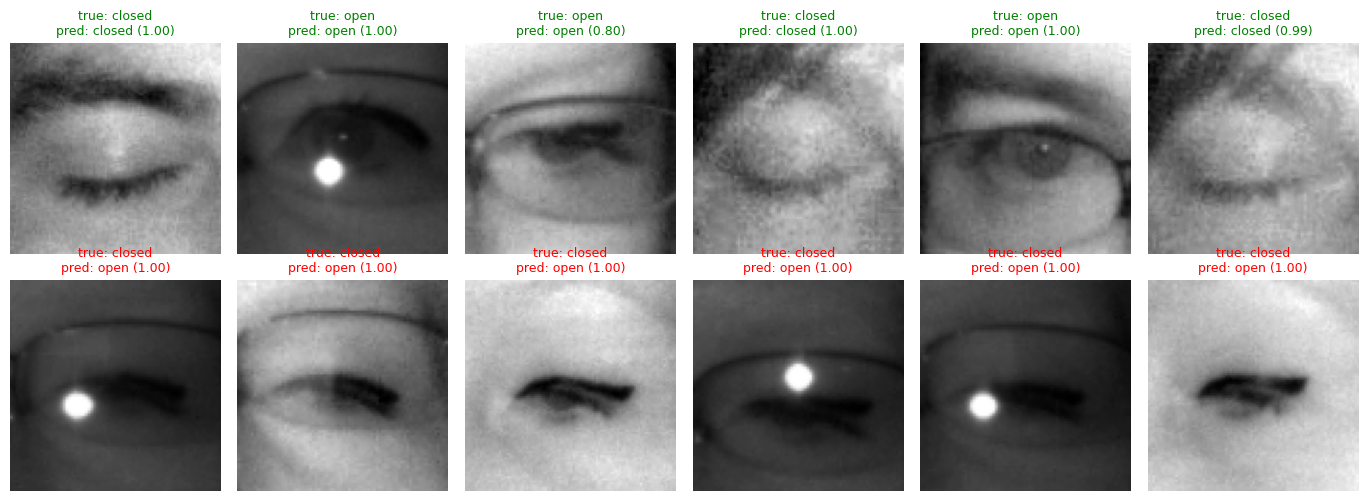

In [18]:
def predict_image(path):
    img = Image.open(path).convert("RGB")
    x = eval_transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
    pred = int(probs.argmax())
    return pred, probs, img

# Show 6 random correct + 6 hardest-wrong predictions
test_df["prob_open"] = all_probs
test_df["error_score"] = abs(test_df["prob_open"] - test_df["eye_state"])
hardest_wrong = test_df[test_df["correct"] == 0].nlargest(6, "error_score")
random_correct = test_df[test_df["correct"] == 1].sample(min(6, (test_df.correct == 1).sum()),
                                                          random_state=SEED)

n_wrong = len(hardest_wrong)
n_right = len(random_correct)
n_cols = max(n_wrong, n_right, 1)

fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 2.3, 5))
if n_cols == 1:
    axes = axes.reshape(2, 1)
label_names = {0: "closed", 1: "open"}

for i, row in enumerate(random_correct.itertuples()):
    pred, probs, img = predict_image(row.path)
    axes[0, i].imshow(img.convert("L"), cmap="gray")
    axes[0, i].set_title(f"true: {label_names[row.eye_state]}\npred: {label_names[pred]} ({probs[pred]:.2f})",
                         fontsize=9, color="green")
    axes[0, i].axis("off")

for i, row in enumerate(hardest_wrong.itertuples()):
    pred, probs, img = predict_image(row.path)
    axes[1, i].imshow(img.convert("L"), cmap="gray")
    axes[1, i].set_title(f"true: {label_names[row.eye_state]}\npred: {label_names[pred]} ({probs[pred]:.2f})",
                         fontsize=9, color="red")
    axes[1, i].axis("off")

# Hide unused axes
for i in range(n_right, n_cols):
    axes[0, i].axis("off")
for i in range(n_wrong, n_cols):
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()


## 10. Summary

The trained model weights are saved at `models/eye_cnn.pt`. The next
notebook (`02_face_training.ipynb`) follows the same structure but uses
engineered MediaPipe features and a small MLP classifier instead of a CNN.

### What goes in the dissertation from this notebook
- The training curves (`eye_training_curves.png`)
- The confusion matrix (`eye_confusion_matrix.png`)
- The accuracy / precision / recall / F1 numbers from §7
- The slice analysis from §8 (glasses, lighting effects) for the Discussion

### What still needs doing for the eye modality
- Wrap inference in a `src/eye/inference.py` module that takes a video,
  runs MediaPipe to crop the eye region per frame, applies this CNN, and
  returns per-frame closure probabilities + a PERCLOS time series.
- This module gets imported by `app.py` (the Gradio demo) at the end of
  the project.
